=== 1. LOADING & PREPROCESSING DATA ===
Data cleaning complete. Saved as 'cleaned_student_data.csv'.

=== 2. DESCRIPTIVE STATISTICS ===
                         Mean   Median  Std Dev    Min      Max
Student_ID            3500.50  3500.50  2020.87    1.0  7000.00
Study_Time_per_Week      9.66     9.60     4.47    0.0    26.10
Daily_Sleep_Duration     7.19     7.20     1.26    3.0    11.00
Math_Score              69.48    70.00    14.78    3.0   100.00
Reading_Score           71.12    71.00    13.33   21.0   100.00
Writing_Score           70.49    71.00    13.35   14.0   100.00
Attendance_(%)          83.09    83.20     5.86   61.9   100.00
Total_Score            100.00   100.00     0.00  100.0   100.00
Average_Score           70.36    70.33     8.01   41.0    96.67

=== 3. GENERATING VISUALIZATIONS ===


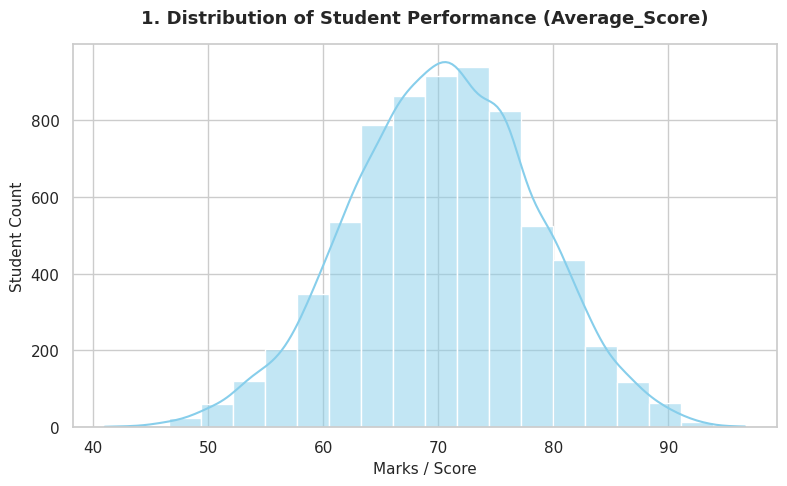

/tmp/ipykernel_2946/1523893815.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


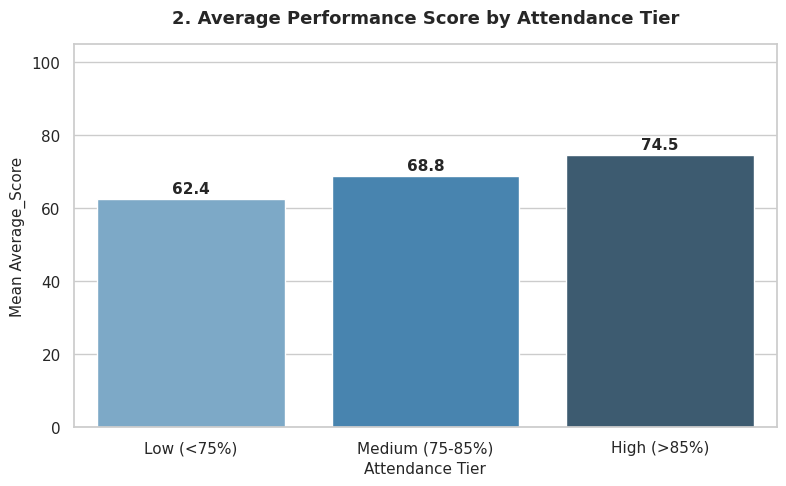

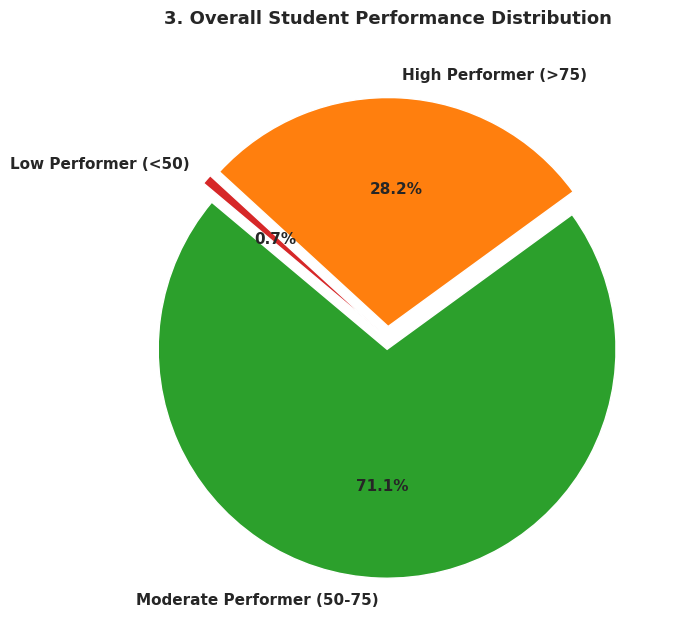


=== 4. CORRELATION & RELATIONSHIP ANALYSIS ===


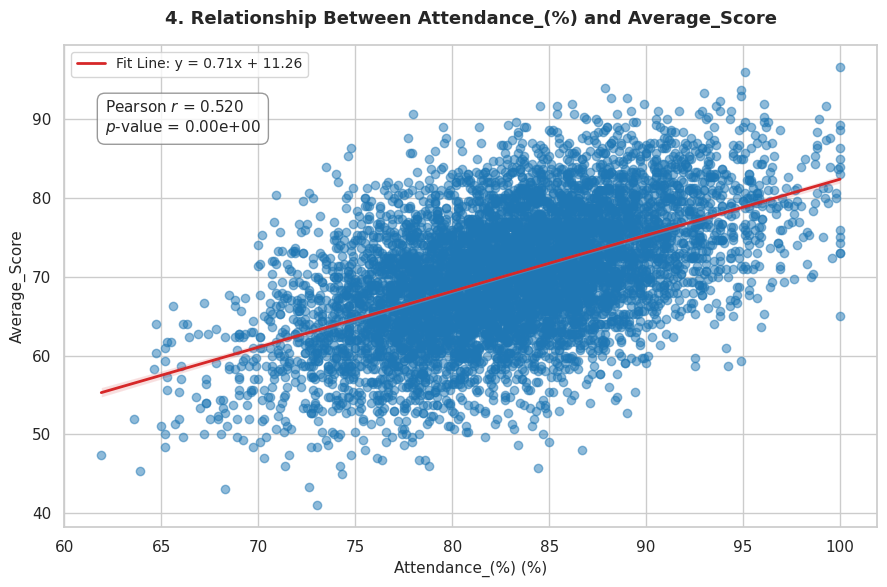


               EXECUTIVE INSIGHTS & RECOMMENDATIONS         
1. Attendance Impact: Students in the "High (>85%)" tier scored an average of 74.52, while those in the "Low (<75%)" tier averaged 62.44.
2. Statistical Association: Strong positive correlation confirmed (r = 0.520).
3. Policy Action: Implement an early warning system for students whose attendance drops below 80% before midterms.


In [3]:
# ==============================================================================
# PROJECT TITLE: STUDENT PERFORMANCE ANALYSIS (LEVEL 1)
# ORGANISATION: COGNEVANCE TECHNOLOGIES
# AUTHOR: DATA ANALYTICS INTERN
# ==============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------------------------
# SETUP & DIRECTORY CREATION
# ------------------------------------------------------------------------------
os.makedirs('charts', exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 11})

print('=== 1. LOADING & PREPROCESSING DATA ===')

# ------------------------------------------------------------------------------
# TASK 1 & 2: DATA LOADING, CLEANING & PREPROCESSING
# ------------------------------------------------------------------------------
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
if not csv_files:
  raise FileNotFoundError(
      'No CSV dataset found! Please upload your dataset file.'
  )

df = pd.read_csv(csv_files[0])
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Remove duplicate records
df = df.drop_duplicates()

# Convert text numbers if any
for col in df.columns:
  if df[col].dtype == 'object':
    cleaned = df[col].astype(str).str.replace('%', '', regex=False).str.strip()
    converted = pd.to_numeric(cleaned, errors='coerce')
    if converted.notnull().sum() > 0.5 * len(df):
      df[col] = converted

# Impute missing values
for col in df.columns:
  if df[col].isnull().sum() > 0:
    if df[col].dtype in ['float64', 'int64']:
      df[col] = df[col].fillna(df[col].median())
    else:
      df[col] = df[col].fillna(df[col].mode()[0])

numeric_df = df.select_dtypes(include=[np.number])

att_cols = [
    c for c in numeric_df.columns if 'attend' in c.lower() or 'percent' in c.lower()
]
score_cols = [
    c
    for c in numeric_df.columns
    if 'score' in c.lower()
    or 'mark' in c.lower()
    or 'grade' in c.lower()
    or 'exam' in c.lower()
]

att_var = att_cols[0] if att_cols else numeric_df.columns[0]
score_var = score_cols[-1] if score_cols else numeric_df.columns[1]

# Range validation
df[att_var] = df[att_var].clip(lower=0, upper=100)
df[score_var] = df[score_var].clip(lower=0, upper=100)
df = df.round(2)

# Save processed dataset
df.to_csv('cleaned_student_data.csv', index=False)
print("Data cleaning complete. Saved as 'cleaned_student_data.csv'.\n")

# ------------------------------------------------------------------------------
# TASK 3: STATISTICAL ANALYSIS & TREND CATEGORIZATION
# ------------------------------------------------------------------------------
print('=== 2. DESCRIPTIVE STATISTICS ===')
stats_summary = numeric_df.agg(['mean', 'median', 'std', 'min', 'max']).T
stats_summary.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
print(stats_summary.round(2))

# Attendance Tier Binning
att_bins = [-1, 75, 85, 100]
att_labels = ['Low (<75%)', 'Medium (75-85%)', 'High (>85%)']
df['Attendance_Tier'] = pd.cut(df[att_var], bins=att_bins, labels=att_labels)

# Performance Category Binning
score_bins = [-1, 50, 75, 100]
score_labels = [
    'Low Performer (<50)',
    'Moderate Performer (50-75)',
    'High Performer (>75)',
]
df['Performance_Category'] = pd.cut(
    df[score_var], bins=score_bins, labels=score_labels
)

# ------------------------------------------------------------------------------
# TASK 4: VISUALIZATION GENERATION (DISPLAY & SAVE)
# ------------------------------------------------------------------------------
print('\n=== 3. GENERATING VISUALIZATIONS ===')

# Chart 1: Score Distribution Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df[score_var], kde=True, color='skyblue', bins=20)
plt.title(
    f'1. Distribution of Student Performance ({score_var})',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Marks / Score', fontsize=11)
plt.ylabel('Student Count', fontsize=11)
plt.tight_layout()
plt.savefig('charts/1_score_distribution_histogram.png', dpi=300)
plt.show()  # Display chart on screen

# Chart 2: Average Score Bar Plot by Attendance Tier
plt.figure(figsize=(8, 5))
tier_avg = (
    df.groupby('Attendance_Tier', observed=False)[score_var]
    .mean()
    .reset_index()
)
bar_plot = sns.barplot(
    x='Attendance_Tier', y=score_var, data=tier_avg, palette='Blues_d'
)
for p in bar_plot.patches:
  bar_plot.annotate(
      f'{p.get_height():.1f}',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 8),
      textcoords='offset points',
      fontweight='bold',
  )
plt.title(
    '2. Average Performance Score by Attendance Tier',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Attendance Tier', fontsize=11)
plt.ylabel(f'Mean {score_var}', fontsize=11)
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig('charts/2_avg_score_by_attendance_bar.png', dpi=300)
plt.show()  # Display chart on screen

# Chart 3: Performance Breakdown Pie Chart
plt.figure(figsize=(7, 7))
category_counts = df['Performance_Category'].value_counts()
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ca02c', '#ff7f0e', '#d62728'],
    explode=(0.05, 0.05, 0.05),
    textprops={'fontsize': 11, 'weight': 'bold'},
)
plt.title(
    '3. Overall Student Performance Distribution',
    fontsize=13,
    fontweight='bold',
    pad=20,
)
plt.tight_layout()
plt.savefig('charts/3_performance_category_pie.png', dpi=300)
plt.show()  # Display chart on screen

# ------------------------------------------------------------------------------
# TASK 5: CORRELATION & REGRESSION ANALYSIS
# ------------------------------------------------------------------------------
print('\n=== 4. CORRELATION & RELATIONSHIP ANALYSIS ===')
r_val, p_val = stats.pearsonr(df[att_var], df[score_var])
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df[att_var], df[score_var]
)

# Chart 4: Scatter Plot with Regression Trendline
plt.figure(figsize=(9, 6))
sns.regplot(
    x=att_var,
    y=score_var,
    data=df,
    scatter_kws={'alpha': 0.5, 'color': '#1f77b4'},
    line_kws={
        'color': '#d62728',
        'linewidth': 2,
        'label': f'Fit Line: y = {slope:.2f}x + {intercept:.2f}',
    },
)
plt.title(
    f'4. Relationship Between {att_var} and {score_var}',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel(f'{att_var} (%)', fontsize=11)
plt.ylabel(f'{score_var}', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.text(
    0.05,
    0.82,
    f'Pearson $r$ = {r_val:.3f}\n$p$-value = {p_val:.2e}',
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(
        boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'
    ),
)
plt.tight_layout()
plt.savefig('charts/4_attendance_vs_scores_scatter.png', dpi=300)
plt.show()  # Display chart on screen

# ------------------------------------------------------------------------------
# TASK 6: EXECUTIVE INSIGHTS & RECOMMENDATIONS
# ------------------------------------------------------------------------------
avg_score_low_att = df[df['Attendance_Tier'] == 'Low (<75%)'][score_var].mean()
avg_score_high_att = df[df['Attendance_Tier'] == 'High (>85%)'][score_var].mean()

print('\n' + '=' * 60)
print('               EXECUTIVE INSIGHTS & RECOMMENDATIONS         ')
print('=' * 60)
print(
    f'1. Attendance Impact: Students in the "High (>85%)" tier scored an average of {avg_score_high_att:.2f}, while those in the "Low (<75%)" tier averaged {avg_score_low_att:.2f}.'
)
print(
    f'2. Statistical Association: Strong positive correlation confirmed (r = {r_val:.3f}).'
)
print(
    '3. Policy Action: Implement an early warning system for students whose attendance drops below 80% before midterms.'
)
print('=' * 60)